תא 1 — Setup (קוד)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.animation as animation
from matplotlib.gridspec import GridSpec
from scipy.ndimage import convolve
import networkx as nx
from IPython.display import HTML

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
})

TEAL   = '#4A9DB5'
CORAL  = '#D4756B'
GOLD   = '#C9A84C'
PURPLE = '#7B68C8'
GREEN  = '#5BAD8F'

rng = np.random.default_rng(42)
print('Setup complete.')

Setup complete.




> Add blockquote
2 — Time-Series: Lotka–Volterra (קוד)


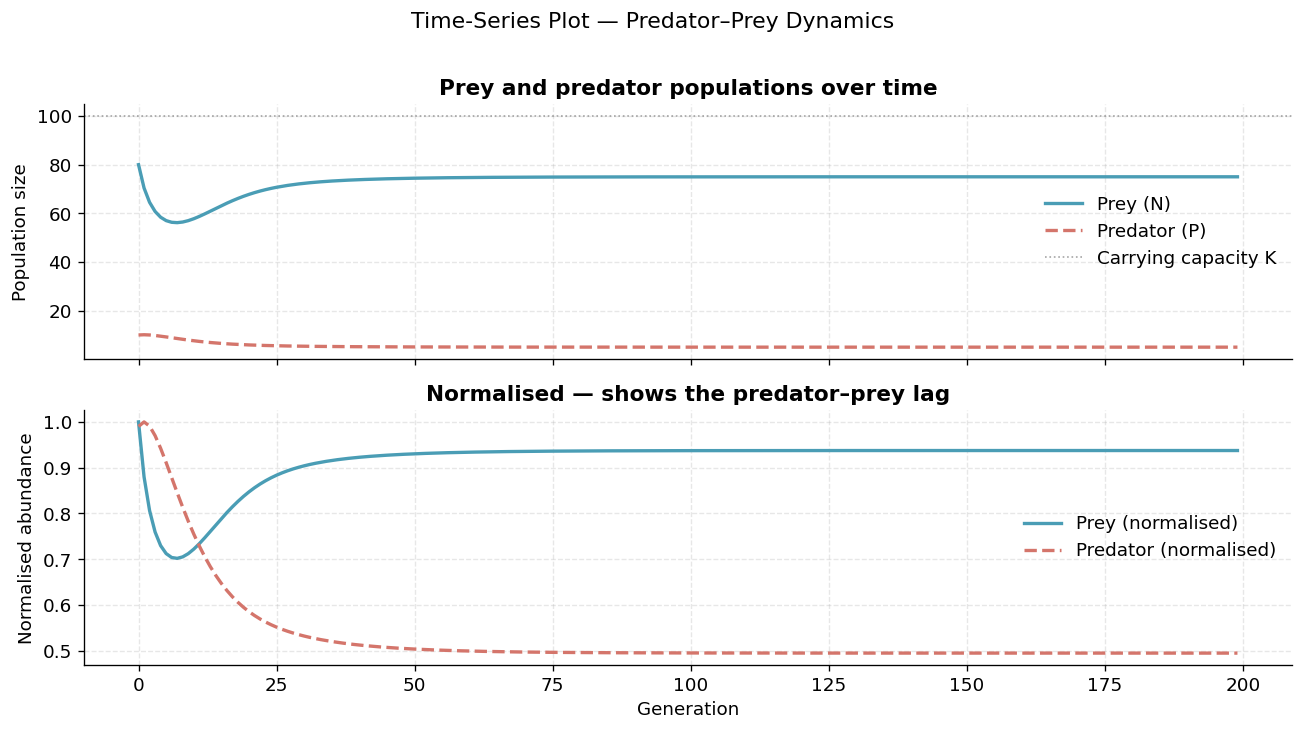

In [ ]:
def simulate_lv(T=200, r=0.4, K=100, a=0.02, e=0.1, m=0.15, N0=80, P0=10):
    N, P = np.zeros(T), np.zeros(T)
    N[0], P[0] = N0, P0
    for t in range(T - 1):
        N[t+1] = max(0, N[t] + r*N[t]*(1 - N[t]/K) - a*N[t]*P[t])
        P[t+1] = max(0, P[t] + e*a*N[t]*P[t] - m*P[t])
    return N, P

T = 200
time = np.arange(T)
N, P = simulate_lv(T=T)

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
fig.suptitle('Time-Series Plot — Predator–Prey Dynamics', y=1.01)

ax = axes[0]
ax.plot(time, N, color=TEAL,  lw=2, label='Prey (N)')
ax.plot(time, P, color=CORAL, lw=2, label='Predator (P)', linestyle='--')
ax.axhline(100, color='gray', lw=1, linestyle=':', alpha=0.7, label='Carrying capacity K')
ax.set_ylabel('Population size')
ax.legend(frameon=False)
ax.set_title('Prey and predator populations over time')

ax2 = axes[1]
ax2.plot(time, N / N.max(), color=TEAL,  lw=2, label='Prey (normalised)')
ax2.plot(time, P / P.max(), color=CORAL, lw=2, label='Predator (normalised)', linestyle='--')

prey_peaks = np.where((N[1:-1] > N[:-2]) & (N[1:-1] > N[2:]))[0] + 1
pred_peaks = np.where((P[1:-1] > P[:-2]) & (P[1:-1] > P[2:]))[0] + 1
if len(prey_peaks) and len(pred_peaks):
    t1 = prey_peaks[0]
    cands = pred_peaks[pred_peaks > t1]
    t2 = cands[0] if len(cands) else pred_peaks[0]
    ax2.annotate('', xy=(t2, P[t2]/P.max()), xytext=(t1, N[t1]/N.max()),
                 arrowprops=dict(arrowstyle='->', color=GOLD, lw=2))
    ax2.text((t1+t2)//2, 0.6, f'lag ≈ {t2-t1} steps',
             ha='center', color=GOLD, fontsize=10, fontweight='bold')

ax2.set_ylabel('Normalised abundance')
ax2.set_xlabel('Generation')
ax2.legend(frameon=False)
ax2.set_title('Normalised — shows the predator–prey lag')

plt.tight_layout()
plt.show()

תא 3 — Phase-Space Diagram (קוד)

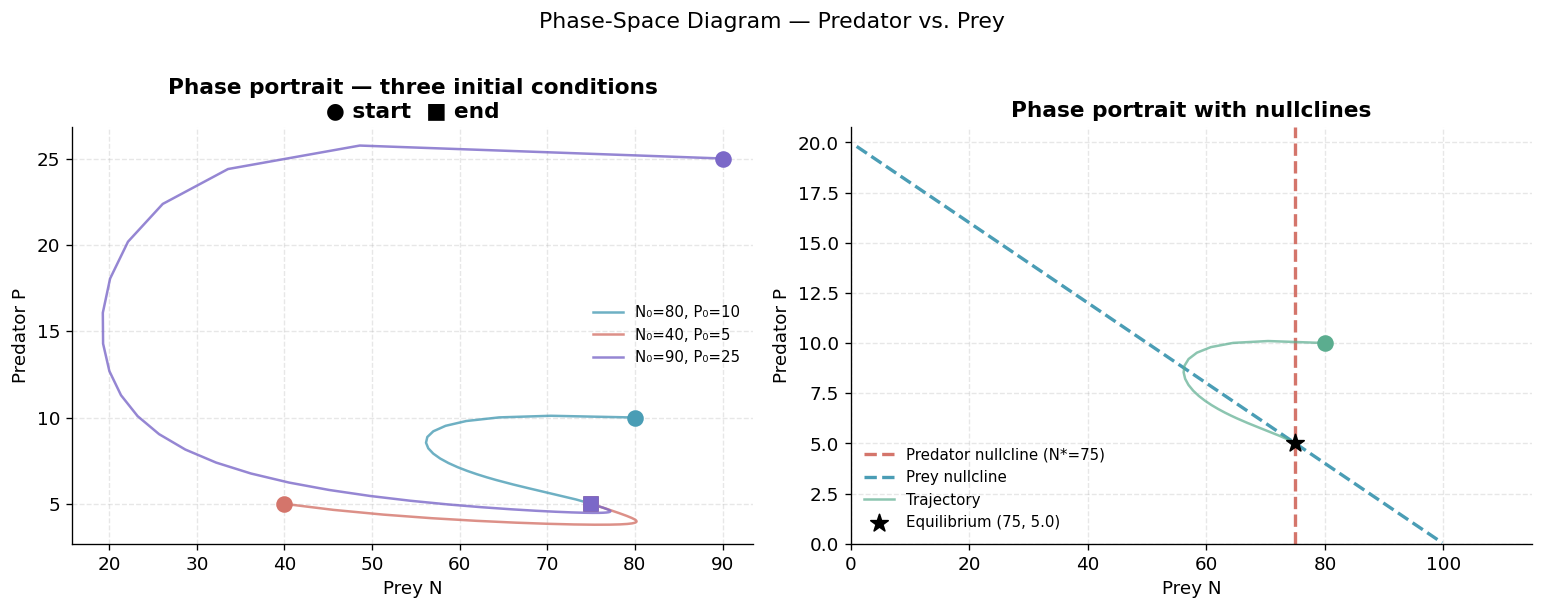

In [ ]:
starts = [(80, 10), (40, 5), (90, 25)]
colors = [TEAL, CORAL, PURPLE]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Phase-Space Diagram — Predator vs. Prey', y=1.01)

ax = axes[0]
for (N0, P0), col in zip(starts, colors):
    Ni, Pi = simulate_lv(T=300, N0=N0, P0=P0)
    ax.plot(Ni, Pi, color=col, alpha=0.8, lw=1.5, label=f'N₀={N0}, P₀={P0}')
    ax.scatter(Ni[0], Pi[0], color=col, s=80, zorder=5, marker='o')
    ax.scatter(Ni[-1], Pi[-1], color=col, s=80, zorder=5, marker='s')
ax.set_xlabel('Prey N'); ax.set_ylabel('Predator P')
ax.set_title('Phase portrait — three initial conditions\n● start  ■ end')
ax.legend(frameon=False, fontsize=9)

ax2 = axes[1]
r, K, a, e, m = 0.4, 100, 0.02, 0.1, 0.15
N_range = np.linspace(1, 110, 300)
P_nc = (r/a) * (1 - N_range/K)
P_nc = np.where(P_nc > 0, P_nc, np.nan)
N_star = m / (e * a)
P_star = (r/a) * (1 - N_star/K)

ax2.axvline(N_star, color=CORAL, lw=2, linestyle='--', label=f'Predator nullcline (N*={N_star:.0f})')
ax2.plot(N_range, P_nc, color=TEAL, lw=2, linestyle='--', label='Prey nullcline')
Ni, Pi = simulate_lv(T=300, N0=80, P0=10)
ax2.plot(Ni, Pi, color=GREEN, alpha=0.7, lw=1.5, label='Trajectory')
ax2.scatter(Ni[0], Pi[0], color=GREEN, s=80, zorder=5)
ax2.scatter(N_star, P_star, color='black', s=120, zorder=6,
            marker='*', label=f'Equilibrium ({N_star:.0f}, {P_star:.1f})')
ax2.set_xlim(0, 115); ax2.set_ylim(0, None)
ax2.set_xlabel('Prey N'); ax2.set_ylabel('Predator P')
ax2.set_title('Phase portrait with nullclines')
ax2.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

תא 4 — Spatial Grid: Cellular Automaton (קוד)

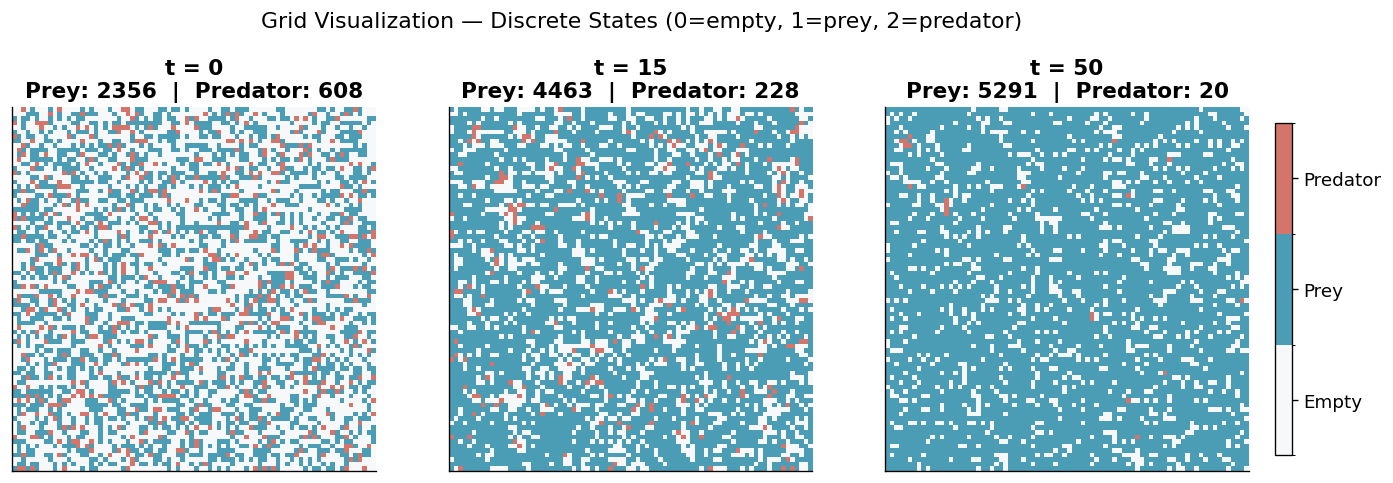

In [ ]:
GRID_SIZE = 80

def init_grid(size, prey_prob=0.4, pred_prob=0.1, seed=42):
    """0=empty, 1=prey, 2=predator"""
    rng = np.random.default_rng(seed)
    grid = np.zeros((size, size), dtype=int)
    grid[rng.random((size,size)) < prey_prob] = 1
    grid[rng.random((size,size)) < pred_prob] = 2
    return grid

def step_grid(grid, birth=0.3, death_prey=0.05, pred_eat=0.15, pred_die=0.1, seed=None):
    rng_s = np.random.default_rng(seed)
    new = grid.copy()
    size = grid.shape[0]
    prey_mask = (grid == 1).astype(float)
    pred_mask = (grid == 2).astype(float)
    kernel = np.array([[1,1,1],[1,0,1],[1,1,1]])
    prey_nb = convolve(prey_mask, kernel, mode='wrap')
    pred_nb = convolve(pred_mask, kernel, mode='wrap')
    r = rng_s.random((size, size))
    empty = grid == 0
    new[empty & (prey_nb > 0) & (r < birth * prey_nb/8)] = 1
    prey = grid == 1
    new[prey & (r < death_prey + pred_eat * pred_nb/8)] = 0
    pred = grid == 2
    r2 = rng_s.random((size, size))
    new[empty & (pred_nb > 0) & (r2 < 0.1 * pred_nb/8)] = 2
    new[pred & (r2 < pred_die)] = 0
    return new

g = init_grid(GRID_SIZE)
snapshots = [g.copy()]
for _ in range(50):
    g = step_grid(g)
    snapshots.append(g.copy())

cmap_discrete = mcolors.ListedColormap(['#F7F8FA', TEAL, CORAL])
norm = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap_discrete.N)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.suptitle('Grid Visualization — Discrete States (0=empty, 1=prey, 2=predator)', y=1.01)
for ax, t in zip(axes, [0, 15, 50]):
    im = ax.imshow(snapshots[t], cmap=cmap_discrete, norm=norm, interpolation='nearest')
    ax.set_title(f't = {t}\nPrey: {(snapshots[t]==1).sum()}  |  Predator: {(snapshots[t]==2).sum()}')
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
cbar = plt.colorbar(im, ax=axes, ticks=[0,1,2], shrink=0.8, pad=0.02, fraction=0.03)
cbar.set_ticklabels(['Empty', 'Prey', 'Predator'])
plt.show()

תא 5 — Heatmap: Continuous Density (קוד)

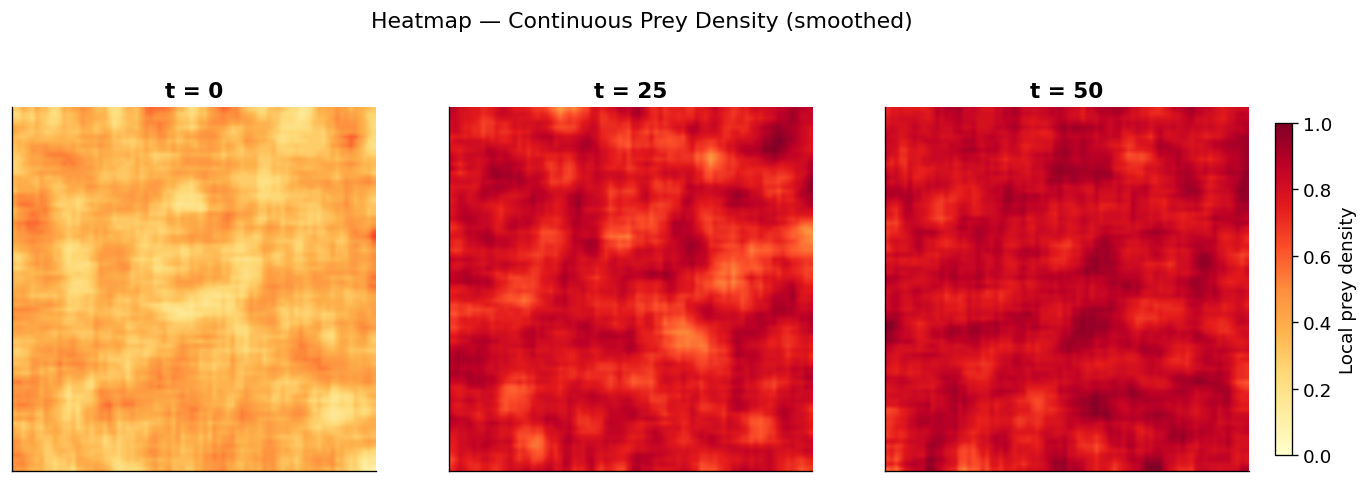

Key: vmin/vmax are FIXED across panels — essential for honest visual comparison.


In [ ]:
from scipy.ndimage import uniform_filter

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.suptitle('Heatmap — Continuous Prey Density (smoothed)', y=1.01)

vmax = 1.0
for ax, t in zip(axes, [0, 25, 50]):
    density = uniform_filter((snapshots[t]==1).astype(float), size=7)
    im = ax.imshow(density, cmap='YlOrRd', vmin=0, vmax=vmax, interpolation='bilinear')
    ax.set_title(f't = {t}')
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)

cbar = plt.colorbar(im, ax=axes, shrink=0.8, pad=0.02, fraction=0.03)
cbar.set_label('Local prey density')
plt.show()

print("Key: vmin/vmax are FIXED across panels — essential for honest visual comparison.")

תא 6 — Network Visualization: Food Web (קוד)

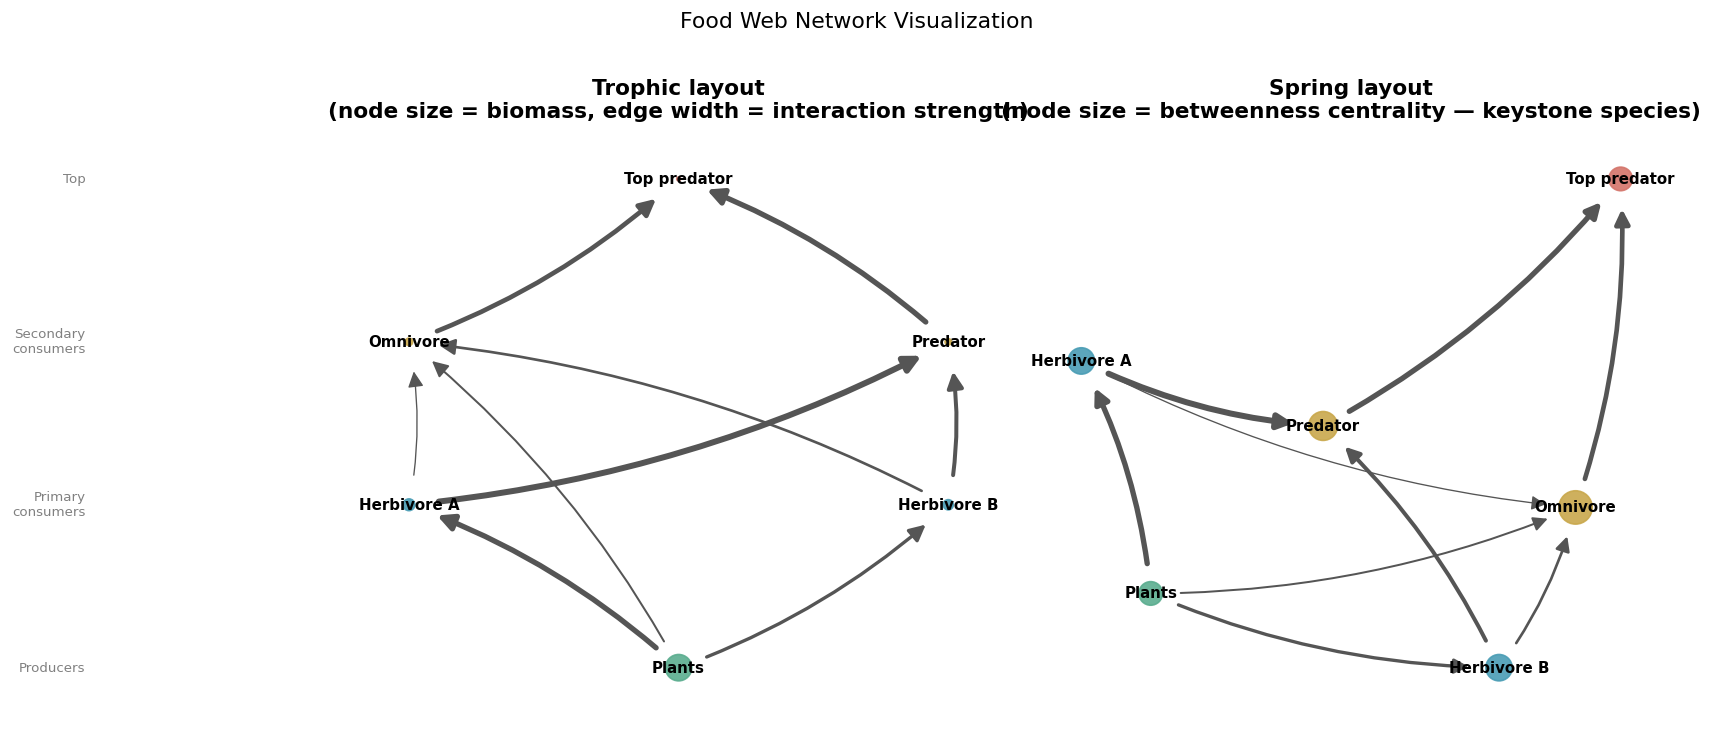

Betweenness centrality:
  Omnivore       0.100  ███
  Predator       0.050  █
  Herbivore A    0.025  
  Herbivore B    0.025  
  Plants         0.000  
  Top predator   0.000  


In [ ]:
G = nx.DiGraph()
edges = [
    ('Plants',     'Herbivore A',  0.8),
    ('Plants',     'Herbivore B',  0.5),
    ('Plants',     'Omnivore',     0.3),
    ('Herbivore A','Predator',     0.9),
    ('Herbivore B','Predator',     0.6),
    ('Herbivore B','Omnivore',     0.4),
    ('Omnivore',   'Top predator', 0.7),
    ('Predator',   'Top predator', 0.8),
    ('Herbivore A','Omnivore',     0.2),
]
for src, dst, w in edges:
    G.add_edge(src, dst, weight=w)

trophic = {'Plants':0,'Herbivore A':1,'Herbivore B':1,'Omnivore':2,'Predator':2,'Top predator':3}
biomass  = {'Plants':1000,'Herbivore A':200,'Herbivore B':150,'Omnivore':80,'Predator':60,'Top predator':20}

level_counts = {}
pos = {}
for node, lvl in sorted(trophic.items(), key=lambda x: x[1]):
    cnt = level_counts.get(lvl, 0)
    pos[node] = (cnt * 2.5, lvl * 2)
    level_counts[lvl] = cnt + 1
max_cnt = max(level_counts.values())
for node, (x, y) in pos.items():
    offset = (max_cnt - level_counts[trophic[node]]) * 1.25
    pos[node] = (x + offset, y)

trophic_colors = ['#5BAD8F','#4A9DB5','#C9A84C','#D4756B']
node_colors = [trophic_colors[trophic[n]] for n in G.nodes()]
node_sizes  = [biomass[n] / 4 for n in G.nodes()]
edge_widths = [G[u][v]['weight'] * 4 for u,v in G.edges()]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Food Web Network Visualization', y=1.01)

ax1 = axes[0]
nx.draw_networkx_nodes(G, pos, ax=ax1, node_color=node_colors, node_size=node_sizes, alpha=0.9)
nx.draw_networkx_labels(G, pos, ax=ax1, font_size=9, font_weight='bold')
nx.draw_networkx_edges(G, pos, ax=ax1, width=edge_widths, edge_color='#555555',
    arrows=True, arrowsize=20, connectionstyle='arc3,rad=0.1',
    min_source_margin=18, min_target_margin=18)
ax1.set_title('Trophic layout\n(node size = biomass, edge width = interaction strength)')
ax1.axis('off'); ax1.grid(False)
for lvl, label in enumerate(['Producers','Primary\nconsumers','Secondary\nconsumers','Top']):
    ax1.text(-1.5, lvl*2, label, fontsize=8, color='gray', va='center', ha='right')

ax2 = axes[1]
bc = nx.betweenness_centrality(G, normalized=True)
bc_sizes = [2000 * bc[n] + 200 for n in G.nodes()]
pos2 = nx.spring_layout(G, seed=7)
nx.draw_networkx_nodes(G, pos2, ax=ax2, node_color=node_colors, node_size=bc_sizes, alpha=0.9)
nx.draw_networkx_labels(G, pos2, ax=ax2, font_size=9, font_weight='bold')
nx.draw_networkx_edges(G, pos2, ax=ax2, width=edge_widths, edge_color='#555555',
    arrows=True, arrowsize=18, connectionstyle='arc3,rad=0.1',
    min_source_margin=18, min_target_margin=18)
ax2.set_title('Spring layout\n(node size = betweenness centrality — keystone species)')
ax2.axis('off'); ax2.grid(False)

plt.tight_layout()
plt.show()

print('Betweenness centrality:')
for node, val in sorted(bc.items(), key=lambda x: -x[1]):
    print(f'  {node:<14} {val:.3f}  {"█" * int(val*30)}')

תא 7 — Animation: Predator–Prey Lattice (קוד)

In [ ]:
g_anim = init_grid(GRID_SIZE, seed=7)
frames_anim = [g_anim.copy()]
for _ in range(80):
    g_anim = step_grid(g_anim)
    frames_anim.append(g_anim.copy())

cmap_d = mcolors.ListedColormap(['#F7F8FA', TEAL, CORAL])
norm_d = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap_d.N)

fig2, ax2 = plt.subplots(figsize=(5, 5))
im2 = ax2.imshow(frames_anim[0], cmap=cmap_d, norm=norm_d,
                 interpolation='nearest', animated=True)
title2 = ax2.set_title('t = 0')
ax2.set_xticks([]); ax2.set_yticks([]); ax2.grid(False)

def update_pred(frame):
    im2.set_data(frames_anim[frame])
    title2.set_text(f't = {frame}  |  prey={(frames_anim[frame]==1).sum()}  pred={(frames_anim[frame]==2).sum()}')
    return [im2, title2]

anim2 = animation.FuncAnimation(fig2, update_pred, frames=len(frames_anim), interval=80, blit=True)
plt.close(fig2)
HTML(anim2.to_jshtml())

תא 8 — Turing / Reaction-Diffusion Pattern (קוד)

/tmp/ipykernel_4067/199859226.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


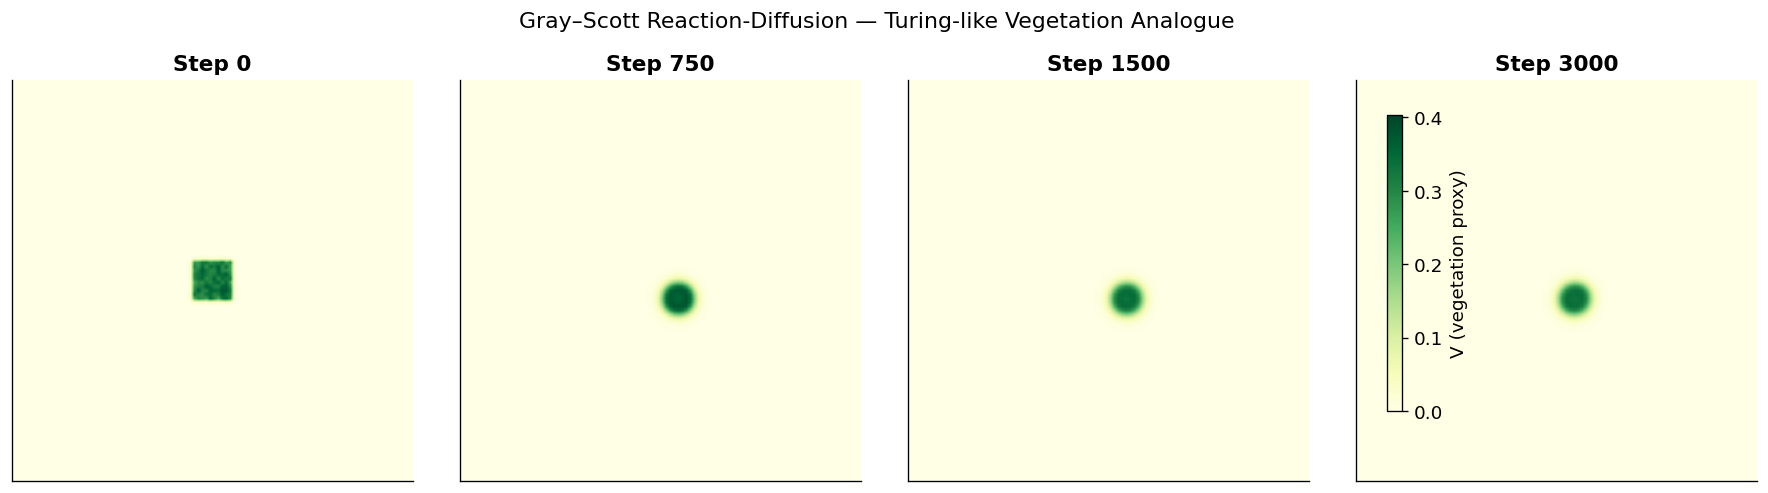

In [ ]:
def laplacian(Z):
    return (np.roll(Z,1,0) + np.roll(Z,-1,0) +
            np.roll(Z,1,1) + np.roll(Z,-1,1) - 4*Z)

N_RD = 100
Du, Dv = 0.16, 0.08
f_rate, k_rate = 0.035, 0.065

rng2 = np.random.default_rng(0)
U = np.ones((N_RD, N_RD))
V = np.zeros((N_RD, N_RD))
U[45:55, 45:55] = 0.5 + rng2.random((10,10)) * 0.1
V[45:55, 45:55] = 0.25 + rng2.random((10,10)) * 0.1

rd_frames = []
for step in range(5000):
    uvv = U * V * V
    dU = Du * laplacian(U) - uvv + f_rate * (1 - U)
    dV = Dv * laplacian(V) + uvv - (f_rate + k_rate) * V
    U += dU; V += dV
    if step % 250 == 0:
        rd_frames.append(V.copy())

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
fig.suptitle('Gray–Scott Reaction-Diffusion — Turing-like Vegetation Analogue', y=1.02)
vmin_rd = 0
vmax_rd = max(fr.max() for fr in rd_frames)
for ax, frame, s in zip(axes, rd_frames[:4], [0, 750, 1500, 3000]):
    im = ax.imshow(frame, cmap='YlGn', vmin=vmin_rd, vmax=vmax_rd, interpolation='bilinear')
    ax.set_title(f'Step {s}')
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
plt.colorbar(im, ax=axes, shrink=0.8, label='V (vegetation proxy)')
plt.tight_layout()
plt.show()

תא 9 — Multi-Panel Dashboard (קוד)

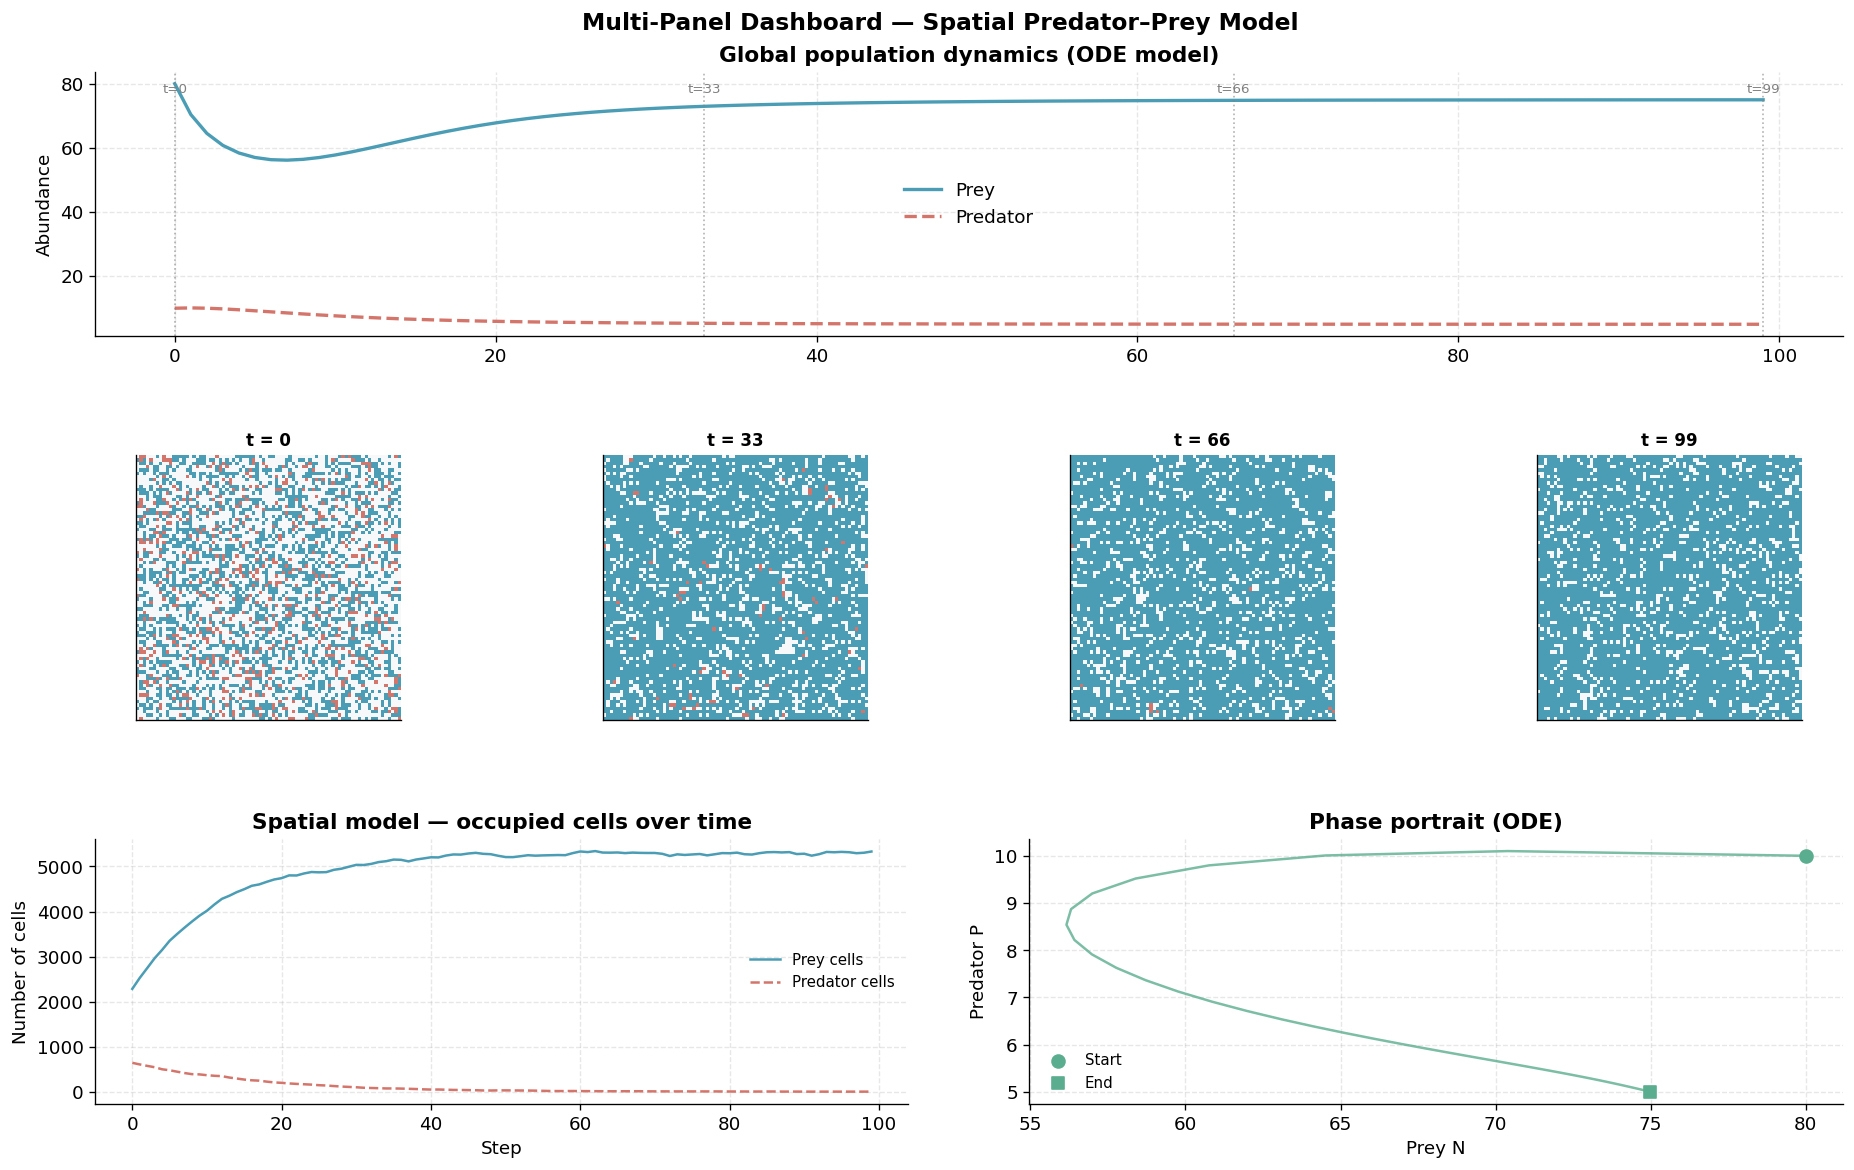

In [ ]:
T_dash = 100
N_ts, P_ts = simulate_lv(T=T_dash)

g_dash = init_grid(GRID_SIZE, seed=99)
prey_counts, pred_counts = [], []
snap_times = [0, 33, 66, 99]
snaps_dash = {}
for t in range(T_dash):
    prey_counts.append((g_dash == 1).sum())
    pred_counts.append((g_dash == 2).sum())
    if t in snap_times:
        snaps_dash[t] = g_dash.copy()
    g_dash = step_grid(g_dash)

fig = plt.figure(figsize=(16, 10))
gs = GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35,
              left=0.06, right=0.97, top=0.93, bottom=0.07)
fig.suptitle('Multi-Panel Dashboard — Spatial Predator–Prey Model', fontsize=14, fontweight='bold')

ax_ts = fig.add_subplot(gs[0, :])
ax_ts.plot(range(T_dash), N_ts[:T_dash], color=TEAL, lw=2, label='Prey')
ax_ts.plot(range(T_dash), P_ts[:T_dash], color=CORAL, lw=2, label='Predator', linestyle='--')
ax_ts.set_ylabel('Abundance')
ax_ts.set_title('Global population dynamics (ODE model)')
ax_ts.legend(frameon=False)
for t in snap_times:
    ax_ts.axvline(t, color='gray', lw=1, linestyle=':', alpha=0.6)
    ax_ts.text(t, ax_ts.get_ylim()[1]*0.92, f't={t}', ha='center', fontsize=8, color='gray')

cmap_d = mcolors.ListedColormap(['#F7F8FA', TEAL, CORAL])
norm_d = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap_d.N)
for col, t in enumerate(snap_times):
    ax_sp = fig.add_subplot(gs[1, col])
    ax_sp.imshow(snaps_dash[t], cmap=cmap_d, norm=norm_d, interpolation='nearest')
    ax_sp.set_title(f't = {t}', fontsize=10)
    ax_sp.set_xticks([]); ax_sp.set_yticks([]); ax_sp.grid(False)

ax_cnt = fig.add_subplot(gs[2, :2])
ax_cnt.plot(prey_counts, color=TEAL, lw=1.5, label='Prey cells')
ax_cnt.plot(pred_counts, color=CORAL, lw=1.5, label='Predator cells', linestyle='--')
ax_cnt.set_xlabel('Step'); ax_cnt.set_ylabel('Number of cells')
ax_cnt.set_title('Spatial model — occupied cells over time')
ax_cnt.legend(frameon=False, fontsize=9)

ax_ph = fig.add_subplot(gs[2, 2:])
ax_ph.plot(N_ts[:T_dash], P_ts[:T_dash], color=GREEN, lw=1.5, alpha=0.8)
ax_ph.scatter(N_ts[0], P_ts[0], color=GREEN, s=60, zorder=5, label='Start')
ax_ph.scatter(N_ts[T_dash-1], P_ts[T_dash-1], s=60, zorder=5, marker='s', color=GREEN, label='End')
ax_ph.set_xlabel('Prey N'); ax_ph.set_ylabel('Predator P')
ax_ph.set_title('Phase portrait (ODE)')
ax_ph.legend(frameon=False, fontsize=9)

plt.show()

תא 10 — Checklist (קוד)

In [ ]:
print("""
CONTENT
  □ Does this figure answer one specific, named ecological question?
  □ Is the pattern type matched to the method?
  □ Are axes labeled with quantity AND units?
  □ Is the color scale fixed across panels/time steps?
  □ Are reference lines present (K, equilibrium, threshold)?

DESIGN
  □ Colorblind-safe? (use viridis/YlOrRd, or add hatching)
  □ Font size readable at final display size (min 9pt)?
  □ Legend in unused whitespace — not over data?
  □ Gridlines subtle (alpha ≤ 0.3) or absent?
  □ Figure title = result statement, not axis description?
      Bad:  "Population size vs. time"
      Good: "Predator peak lags prey by ~6 generations"

ECOLOGICAL INTERPRETATION
  □ Time window long enough for complete pattern?
  □ Uncertainty shown? (confidence bands, multiple runs)
  □ Caption explains WHAT TO LOOK FOR, not just what was plotted?

CODE HYGIENE
  □ rng seeded for reproducibility?
  □ plt.savefig('fig.pdf', dpi=300, bbox_inches='tight')
  □ All parameters defined at top, not buried in loop?
""")


CONTENT
  □ Does this figure answer one specific, named ecological question?
  □ Is the pattern type matched to the method?
  □ Are axes labeled with quantity AND units?
  □ Is the color scale fixed across panels/time steps?
  □ Are reference lines present (K, equilibrium, threshold)?

DESIGN
  □ Colorblind-safe? (use viridis/YlOrRd, or add hatching)
  □ Font size readable at final display size (min 9pt)?
  □ Legend in unused whitespace — not over data?
  □ Gridlines subtle (alpha ≤ 0.3) or absent?
  □ Figure title = result statement, not axis description?
      Bad:  "Population size vs. time"
      Good: "Predator peak lags prey by ~6 generations"

ECOLOGICAL INTERPRETATION
  □ Time window long enough for complete pattern?
  □ Uncertainty shown? (confidence bands, multiple runs)
  □ Caption explains WHAT TO LOOK FOR, not just what was plotted?

CODE HYGIENE
  □ rng seeded for reproducibility?
  □ plt.savefig('fig.pdf', dpi=300, bbox_inches='tight')
  □ All parameters defined at top,


תא 11 — Your Turn (קוד)

In [ ]:
# ================================================================
# STEP 1: Write your pattern statement (as a comment)
# ================================================================
# "My [model] produces [pattern] which is best shown with
#  [method] because [reason]."
#
# Example:
#   "My Game of Life simulation shows spatial clustering of live
#    cells that intensifies over 50 generations — best shown with
#    an animated heatmap because the pattern moves across the grid."

# ================================================================
# STEP 2: Load or simulate your data
# ================================================================
# your_data = ...

# ================================================================
# STEP 3: Adapt the code from the relevant section above
# ================================================================
# Population dynamics  → copy Cell 2 or 3
# Spatial pattern      → copy Cell 4 or 5
# Species interactions → copy Cell 6
# Animation            → copy Cell 7
# Multi-panel view     → copy Cell 9

print("Template ready.")

Template ready.
